# Exploración de Datos e Ingeniería de Características
**Proyecto:** Modelo de Probabilidad de Default - Andina Crédito

**Objetivo:** Preparar el entorno de datos, tratar anomalías y generar variables predictivas (Feature Engineering) para apoyar la toma de decisiones del equipo de Riesgo.

In [1]:
# 0. Librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Configuración inicial
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

# 1. Carga de datos
try:
    train = pd.read_csv('data/train.csv')
    test = pd.read_csv('data/test.csv')
    print(f"Dimensiones Train: {train.shape}")
    print(f"Dimensiones Test: {test.shape}")
except FileNotFoundError:
    print("Error: Verificar la ruta de los archivos en la carpeta 'data/'.")

Dimensiones Train: (45300, 21)
Dimensiones Test: (12000, 20)


## 1. Análisis de la Variable Objetivo (Target)
Evaluamos la distribución de `default_12m` para comprender la tasa base de incumplimiento. Como es habitual en el sector financiero, nos enfrentamos a un problema de clases desbalanceadas.

default_12m
0    90.068433
1     9.931567
Name: proportion, dtype: float64


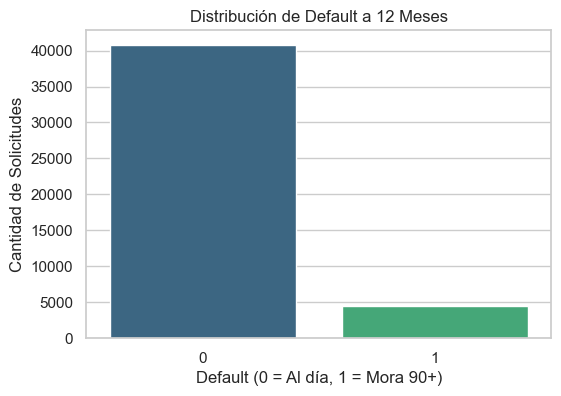

In [2]:
# Distribución del Target
distribucion_target = train['default_12m'].value_counts(normalize=True) * 100
print(distribucion_target)

# Visualización
plt.figure(figsize=(6, 4))
sns.countplot(data=train, x='default_12m', palette='viridis')
plt.title('Distribución de Default a 12 Meses')
plt.ylabel('Cantidad de Solicitudes')
plt.xlabel('Default (0 = Al día, 1 = Mora 90+)')
plt.show()

Se observa un marcado desequilibrio en la variable objetivo, donde aprox. el 10% de las solicitudes caen en default, frente a un 90% de créditos sanos. Esta proporción es coherente con la dinámica esperable en una cartera de créditos de consumo. Este descubrimiento confirma que, en la etapa de modelado, deberemos priorizar métricas de evaluación robustas ante el desbalance, tales como el área bajo la curva Precision-Recall (PR-AUC) o el F1-Score, en lugar de depender exclusivamente del Accuracy.

## 2. Calidad de Datos: Tratamiento de Nulos Estructurales
Al analizar los valores faltantes en `antiguedad_laboral_meses`, se identifica que corresponden estructuralmente a los segmentos de trabajadores `informal` y `jubilado`. En lugar de imputar la media poblacional (lo cual introduciría ruido), se asigna un valor constante (`-1`) para que los algoritmos basados en árboles capturen este patrón como una categoría independiente.

In [3]:
# Verificación de la hipótesis de nulos
nulos_laboral = train[train['antiguedad_laboral_meses'].isnull()]
print("Distribución de tipo de empleo en nulos de antigüedad laboral:")
print(nulos_laboral['tipo_empleo'].value_counts())

Distribución de tipo de empleo en nulos de antigüedad laboral:
tipo_empleo
informal    5761
jubilado    1539
Name: count, dtype: int64


Los resultados confirman que la totalidad de los valores nulos en la antigüedad laboral pertenecen exclusivamente a los segmentos `informal` y `jubilado`. Esto demuestra que la ausencia de datos no es un error de los sistemas de captura, sino una característica intrínseca del perfil del solicitante. Al tratar estos casos con un valor constante (`-1`), permitimos que los algoritmos reconozcan este patrón estructural sin distorsionar la media o mediana de los trabajadores dependientes e independientes.

## 3. Detección de Anomalías: Error de Digitación en Ingresos
Se detecta una concentración anómala de solicitudes con ingresos declarados irracionalmente bajos (ej. valores inferiores a $10.000 CLP). Dado que los montos solicitados y las deudas en el sistema mantienen escalas lógicas, se concluye que existe un error de digitación sistemático donde los montos fueron ingresados en "miles de pesos". Se aplica un factor de corrección.

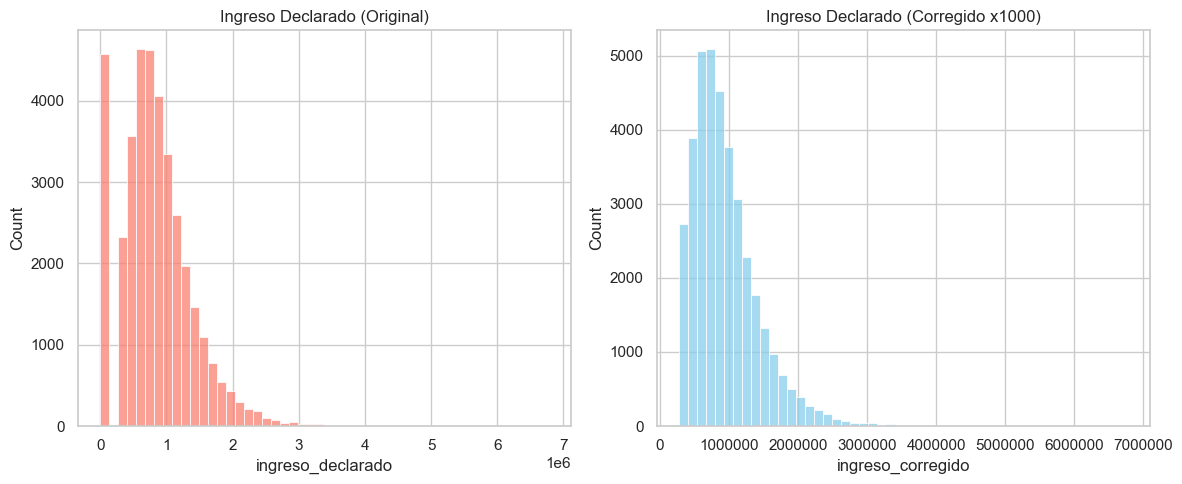

In [4]:
# Visualización del efecto de la corrección
df_plot = train[['ingreso_declarado']].copy().dropna()
df_plot['ingreso_corregido'] = np.where(df_plot['ingreso_declarado'] < 10000, 
                                        df_plot['ingreso_declarado'] * 1000, 
                                        df_plot['ingreso_declarado'])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(df_plot['ingreso_declarado'], bins=50, ax=axes[0], color='salmon')
axes[0].set_title('Ingreso Declarado (Original)')
sns.histplot(df_plot['ingreso_corregido'], bins=50, ax=axes[1], color='skyblue')
axes[1].set_title('Ingreso Declarado (Corregido x1000)')
axes[1].ticklabel_format(style='plain', axis='x')
plt.tight_layout()
plt.show()

La comparativa visual demuestra cómo la corrección aplicada restituye la distribución del ingreso a parámetros lógicos y esperables para el mercado. El gráfico original mostraba una concentración artificial cerca del valor cero, lo que habría generado un cálculo erróneo de la carga financiera (sobreestimando el nivel de endeudamiento de esos clientes). La distribución corregida presenta una curva de asimetría positiva característica de las variables de ingresos, proporcionando una base mucho más limpia para la creación del *Ratio Deuda/Ingreso*.

## 4. Pipeline de Preprocesamiento y Feature Engineering
Se consolida la lógica de limpieza y se generan nuevas características, como el **Ratio Deuda/Ingreso**, fundamental para la evaluación de riesgo crediticio. Posteriormente, se aplica *One-Hot Encoding* a las variables categóricas. Finalmente, se divide el conjunto de entrenamiento utilizando una validación temporal (*Out-of-Time*) para simular el comportamiento del modelo en producción.

In [5]:
def preparar_datos(df):
    df_prep = df.copy()
    df_prep['fecha_solicitud'] = pd.to_datetime(df_prep['fecha_solicitud'])
    
    # 1. Corrección de ingresos anómalos
    condicion_bug = (df_prep['ingreso_declarado'] < 10000) & (df_prep['ingreso_declarado'].notnull())
    df_prep.loc[condicion_bug, 'ingreso_declarado'] = df_prep.loc[condicion_bug, 'ingreso_declarado'] * 1000
    
    # 2. Control de nulos
    df_prep['ingreso_declarado_nulo'] = df_prep['ingreso_declarado'].isnull().astype(int)
    df_prep['ingreso_declarado'] = df_prep['ingreso_declarado'].fillna(-1)
    df_prep['antiguedad_laboral_meses'] = df_prep['antiguedad_laboral_meses'].fillna(-1)
    
    # 3. Feature Engineering: Carga Financiera
    df_prep['ratio_deuda_ingreso'] = np.where(df_prep['ingreso_declarado'] > 0, 
                                              df_prep['deuda_sistema'] / df_prep['ingreso_declarado'], 
                                              -1)
    
    # 4. Variables Categóricas
    vars_categoricas = ['tipo_empleo', 'region', 'canal', 'dia_semana_solicitud']
    df_prep = pd.get_dummies(df_prep, columns=vars_categoricas, drop_first=True)
    
    return df_prep

# Aplicación del pipeline
train_prep = preparar_datos(train)
test_prep = preparar_datos(test)

# Estrategia Out-of-Time (Corte en Noviembre 2024)
fecha_corte = pd.to_datetime('2024-11-01')

# Separación de features y target
features_to_drop = ['id_solicitud', 'fecha_solicitud', 'default_12m']

X_train = train_prep[train_prep['fecha_solicitud'] < fecha_corte].drop(columns=features_to_drop)
y_train = train_prep[train_prep['fecha_solicitud'] < fecha_corte]['default_12m']

X_val = train_prep[train_prep['fecha_solicitud'] >= fecha_corte].drop(columns=features_to_drop)
y_val = train_prep[train_prep['fecha_solicitud'] >= fecha_corte]['default_12m']

print(f"Dimensiones X_train (Antes de Nov 2024): {X_train.shape}")
print(f"Dimensiones X_val (Desde Nov 2024): {X_val.shape}")

Dimensiones X_train (Antes de Nov 2024): (33629, 42)
Dimensiones X_val (Desde Nov 2024): (11671, 42)


Se ha consolidado con éxito el espacio de características (*feature space*). La estrategia de validación temporal (*Out-of-Time*) nos ha dejado con un conjunto de entrenamiento robusto (datos anteriores a noviembre de 2024) y un conjunto de validación que simula el futuro (datos desde noviembre de 2024 en adelante). Esta decisión metodológica asegura que la evaluación del rendimiento del modelo será honesta y reflejará con precisión el comportamiento esperado al momento de su paso a producción.

## 5. Exportación de Matrices de Trabajo
Guardamos las matrices preprocesadas para utilizarlas en la fase de modelado de forma independiente y modular.

In [6]:
# Guardar matrices procesadas en la carpeta data
X_train.to_csv('data/X_train_prep.csv', index=False)
y_train.to_csv('data/y_train_prep.csv', index=False)
X_val.to_csv('data/X_val_prep.csv', index=False)
y_val.to_csv('data/y_val_prep.csv', index=False)

# Guardar el test set para scorear al final
test_prep_export = test_prep.drop(columns=['fecha_solicitud'])
test_prep_export.to_csv('data/test_prep.csv', index=False)

print("Archivos exportados exitosamente para la etapa de modelado.")

Archivos exportados exitosamente para la etapa de modelado.
